# BLAES Units Rhythmicity Analyses

This notebook contains code for analyzing spike train data from the BLAES experiments. First, I contrast the ISIs from the stim- and no-stim to determine if there is a clear difference in the rate of spiking across conditions. Next, I perform a spectral analysis of the spiking data by using a point-process adapted multitaper estimation.

---

> *Contact: Justin Campbell (justin.campbell@hsc.utah.edu)*  
> *Version: 08/21/2024*

## 1. Import Libraries

In [1]:
# General
import os
import re
import glob
import numpy as np
import numba as nb
import pandas as pd

# Signal processing
from scipy.signal import butter, hilbert, filtfilt
from spiketools.measures.conversions import convert_times_to_train
import scipy.ndimage as ndimage

# Plotting
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import Rectangle
from pylab import *

# Stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.genmod.families import Poisson
from statsmodels.distributions.empirical_distribution import ECDF
from scipy.stats import wilcoxon, ranksums, norm, ks_2samp, chi2

# Nitime
from nitime.algorithms import multi_taper_psd
from nitime.utils import dpss_windows

# Notebook settings
%matplotlib inline
# %config InlineBackend.figure_format='retina'
%config InlineBackend.figure_format='svg'

## 2. Set Paths & Parameters

In [2]:
# Params
fs = 30000
export = True

# Define paths
proj_path = '/Volumes/Hippocampus/BLAESUnits' # G-DRIVE Armor ATD External Drive
data_path = os.path.join(proj_path, 'Data_30k')
results_path = '/Users/justincampbell/Library/CloudStorage/GoogleDrive-u0815766@gcloud.utah.edu/My Drive/Research Projects/BLAESUnits/Results/'

# Get list of sessions
sessions = os.listdir(results_path)
sessions = [pID for pID in sessions if re.search(r'\d+$', pID)]

In [3]:
# Analysis flags
run_ISI_contrast = False
run_specgram = True

## 3. Contrast Stim/No-Stim Trial ISIs

In [4]:
def getTrialISIs(events, stim_epochs, nostim_epochs, unit, show = False):
    '''
    This function will plot the ISI distributions for a given unit across stim and no-stim conditions.
    
    Inputs:
    - events: Spike events [DataFrame]
    - stim_epochs: Matrix of start and end times for each trial in the stim condition [DataFrame]
    - nostim_epochs: Matrix of start and end times for each trial in the no-stim condition [DataFrame]
    - unit: Unit to analyze [str]
    - show: Display the plot [bool]
    
    Outputs:
    - ISI distributions (*_ISIContrast.pdf)
    '''
    
    spike_events = []
    for i, epochs in enumerate([stim_epochs, nostim_epochs]):    
        
        # Get unit data
        unitDF = events.copy()
        unitDF['Chan-Unit'] = unitDF['Channel'].astype(str) + '-' + unitDF['Unit'].astype(str)
        unitDF = unitDF[unitDF['Chan-Unit'] == unit]
        unitDF['TimeStamps'] = unitDF['TimeStamps'].astype('int')
        n_trials = epochs.shape[1]
        if i == 0:
            epoch_type = 'Stim'
        else:
            epoch_type = 'NoStim'

        # Get spike events for each trial
        epochSpikes = []
        for ii in range(n_trials):
            epoch_start = epochs.iloc[:,ii].min()
            stim_start = epoch_start + (fs)
            epoch_end = epochs.iloc[:,ii].max()
            epochDF = unitDF[(unitDF['TimeStamps'] >= epoch_start) & (unitDF['TimeStamps'] <= epoch_end)]
            epochDF = epochDF.reset_index(drop = True)
            epochDF['TimeAdj'] = (epochDF['TimeStamps'] - stim_start) / fs
            epochDF['Trial'] = ii
            epochDF['Condition'] = epoch_type
            epochSpikes.append(epochDF)
        spike_events.append(pd.concat(epochSpikes))
    spikesDF = pd.concat(spike_events)
    spikesDF = spikesDF.reset_index(drop = True)
    spikesDF['TimeAdj'] = spikesDF['TimeAdj'] * 1000
    
    # Get ISIs
    isis_stim = []
    isis_nostim = []
    for i, cond in enumerate(['Stim', 'NoStim']):    
        for ii in range(n_trials):
            sample = spikesDF[(spikesDF['Condition'] == cond) & (spikesDF['Trial'] == ii)]
            trial_isis = sample['TimeAdj'].diff().dropna().values
            if i == 0:
                isis_stim.append(trial_isis)
            else:
                isis_nostim.append(trial_isis)
            
    # Concatenate ISIs and create a DataFrame
    isis_stim = np.concatenate(isis_stim)
    isis_nostim = np.concatenate(isis_nostim)
    isiDF = pd.DataFrame({'ISI': np.concatenate([isis_stim, isis_nostim]), 'Condition': ['Stim'] * len(isis_stim) + ['NoStim'] * len(isis_nostim)})
    
    try:
        # Compare ISI distributions with a ks-test
        ks_stat, ks_p = ks_2samp(isis_stim, isis_nostim)

        # Plot ISI distributions
        fig, axes = plt.subplots(2, 1, figsize = (4, 3), sharex = True)
        plotPal = [sns.color_palette('flare')[5], sns.color_palette('flare')[0]]
        bins = np.linspace(0, 1000, 50)
        sns.histplot(isiDF[isiDF['Condition'] == 'Stim'], x = 'ISI', bins = bins, color = plotPal[0], ax = axes[0])
        sns.histplot(isiDF[isiDF['Condition'] == 'NoStim'], x = 'ISI', bins = bins, color = plotPal[1], ax = axes[1])

        # Figure aesthetics
        for ax in axes:
            ax.axvspan(125, 333, color = 'grey', alpha = 0.1, zorder = -1)
            ax.set_ylabel('Count', fontsize = 'large')
        sns.despine(top = True, right = True)
        plt.xlim(0, 1001)
        plt.xticks(np.arange(0, 1001, 250), fontsize = 'small')
        plt.xlabel('ISI (ms)', fontsize = 'large')
        handles = [Rectangle((0, 0), 1, 1, color = plotPal[0]), Rectangle((0, 0), 1, 1, color = plotPal[1]), Rectangle((0, 0), 1, 1, color = '#e4e4e4')]
        axes[0].legend(title = '', handles = handles, labels = ['Stim', 'No-Stim', '$\Theta$ (3-8 Hz)'], title_fontsize = 'small', fontsize = 'x-small', bbox_to_anchor = (1, 1))
        axes[0].text(s = '$D$ = %.2f, $p$ = %.3f' % (ks_stat, ks_p), fontsize = 'small', x = 0.5, y = 1.2, ha = 'center', va = 'center', transform = axes[0].transAxes)
        plt.suptitle(pID + ', ' + unit, fontsize = 'large', y = 1.05)
    
        # Export & Display
        if export:
            if not os.path.exists(os.path.join(save_path, 'ISIs')):
                os.mkdir(os.path.join(save_path, 'ISIs'))
            plt.savefig((os.path.join(save_path, 'ISIs', unit + '_ISIContrast' + '.pdf')), dpi = 1200, bbox_inches = 'tight')
        
    except:
        pass
        
    if show:
        plt.show()
    else:
        plt.close()

In [5]:
if run_ISI_contrast:
    
    for pID in sessions:
        # Define path to save plots for given session    
        save_path = os.path.join(results_path, pID)

        # Get stim/no-stim epochs and events
        stim_epochs = pd.read_csv(os.path.join(results_path, pID, 'StimEpochs.csv'), index_col = 0)
        nostim_epochs = pd.read_csv(os.path.join(results_path, pID, 'NoStimEpochs.csv'), index_col = 0)
        events = pd.read_csv(os.path.join(results_path, pID, 'Events.csv'), index_col = 0)
        events['Chan-Unit'] = events['Channel'] + '-' + events['Unit'].astype(str)

        # Get ISIs for each unit
        for unit in events['Chan-Unit'].unique():
            getTrialISIs(events, stim_epochs, nostim_epochs, unit)

## 4. Spectral Analyses
Implementation of rhythmicity analyses was based on [*Case Studies in Neural Data Analysis, Ch.10: Analysis of Rhythmic Spike Train Data*](https://mark-kramer.github.io/Case-Studies-Python/10.html).

In [6]:
# pID = 'BJH02501'
# unit = 'mRHIP3-1'
pID = 'UIC20230201'
unit = 'mROFC8-1'
# pID = 'BJH03301'
# unit = 'mLAMY5-1'

events = pd.read_csv(os.path.join(results_path, pID, 'Events.csv'), index_col = 0)
stim_epochs = pd.read_csv(os.path.join(results_path, pID, 'StimEpochs.csv'), index_col = 0)
nostim_epochs = pd.read_csv(os.path.join(results_path, pID, 'NoStimEpochs.csv'), index_col = 0)

In [7]:
def plotPSRaster(epochs, unit, show = True):
    '''
    Plot unit raster for peri-stimulation epochs.
    
    Arguments:
        epochs (np.ndarray): array of peri-stimulation epochs (indices)
        unit (str): unit label
        color_idx (int): index of color in palette
        show (bool): show figure
        save (bool): save figure
        
    Returns:
        None
    '''

    # Figure parameters
    # fig, axes = plt.subplots(2, 1, figsize = (4, 4))
    fig = plt.figure(figsize = (4,4), constrained_layout = True)
    gs = gridspec.GridSpec(ncols=1, nrows=8, figure=fig)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1:6])
    ax3 = fig.add_subplot(gs[6:8])

    # Get unit data
    unitDF = events.copy()
    unitDF['Chan-Unit'] = unitDF['Channel'].astype(str) + '-' + unitDF['Unit'].astype(str)
    unitDF = unitDF[unitDF['Chan-Unit'] == unit]
    unitDF['TimeStamps'] = unitDF['TimeStamps'].astype('int')
    n_trials = epochs.shape[1]

    # Plot raster
    epochSpikes = []
    for i in range(n_trials):
        epoch_start = epochs.iloc[:, i].min()
        stim_start = epoch_start + (fs)
        epoch_end = epochs.iloc[:, i].max()
        epochDF = unitDF[(unitDF['TimeStamps'] >= epoch_start) & (unitDF['TimeStamps'] <= epoch_end)]
        epochDF = epochDF.reset_index(drop = True)
        epochDF['TimeAdj'] = (epochDF['TimeStamps'] - stim_start) / fs
        epochSpikes.append(epochDF)
        for spike in range(epochDF.shape[0]):
            spike_time = (epochDF.iloc[spike]['TimeStamps'] - stim_start) / fs # set stim at t0, convert samples -> sec
            y_pos = i + 1
            ax2.vlines(spike_time, y_pos - 0.4, y_pos + 0.4, linewidth = 2)
            
    # Plot binned FR
    spikesDF = pd.concat(epochSpikes)
    spikesDF = spikesDF.reset_index(drop = True)
    binSize = 0.1 # time (s)
    bins = np.arange(-1, 2.1, binSize)
    maxSpikes = np.histogram(spikesDF['TimeAdj'], bins = bins)[0].max()
    sns.histplot(spikesDF['TimeAdj'], bins = bins, kde = True, kde_kws = {'bw_adjust': 0.2, 'cut': 3, 'clip': [-1,2]}, ax = ax3)

    # Shade times where BLA was stimulated
    for ax in [ax1, ax2, ax3]:
        ax.axvspan(0, 1, color = 'grey', alpha = 0.1, zorder = -10)
        ax.set_xlim([-1, 2.05])
        sns.despine(top = True, right = True)

    # Figure aesthetics
    ax1.set_xticks([-1, 0, 1, 2], ['', '', '', ''])
    ax1.set_yticks([])
    ax2.set_xlabel('')
    ax2.set_xticks([-1, 0, 1, 2], ['', '', '', ''])
    ax2.set_ylabel('Trial', fontsize = 'large', labelpad= 10)
    ax2.set_ylim([0, n_trials+1])
    ax2.set_yticks([1, n_trials], ['1', str(n_trials)], fontsize = 'small')
    ax2.set_xlabel('')
    ax3.set_xlabel('Time (s)', fontsize = 'large')
    ax3.set_xticks([-1, 0, 1, 2], ['-1', '0', '1', '2'], fontsize = 'small')
    ax3.set_ylabel('FR (Hz)', fontsize = 'large', labelpad = 7)
    ax3.set_yticks([0, maxSpikes], [0, np.round((maxSpikes / n_trials) * 10, 1)], fontsize = 'small')
    ax1.set_title(unit, fontsize = 'x-large', fontweight = 'bold', pad = 15)
    sns.despine(top = True, right = True, left = True, ax = ax1)

    if show == False:
        plt.close()
    
    return epochSpikes

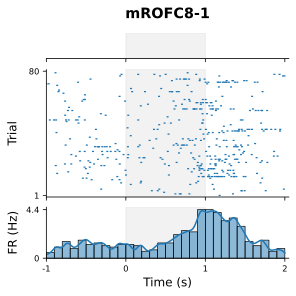

In [8]:
epochSpikes = plotPSRaster(stim_epochs, unit)

In [9]:
Fs = 1000

for i, df in enumerate(epochSpikes):
    df['Trial'] = i
    
spikesDF = pd.concat(epochSpikes)
spikesDF = spikesDF.reset_index(drop = True)
spikesDF['TimeAdj'] = spikesDF['TimeAdj'] + 1
spikesDF['TimeAdj'] = spikesDF['TimeAdj'] * Fs
spikesDF['TimeAdj'] = spikesDF['TimeAdj'].astype('int')

spike_trains = []
for i in range(spikesDF['Trial'].max() + 1):
    trialDF = spikesDF[spikesDF['Trial'] == i]
    spike_times = trialDF['TimeAdj'].values
    spike_times.sort()
    spike_train = np.zeros((Fs * 3, 1))
    spike_train = [1 if i in spike_times else 0 for i in range(Fs * 3)]
    spike_trains.append(spike_train)
    
spike_trains = np.array(spike_trains)

/var/folders/mq/6f6ky9r97r1_mqfg3vjq9fd00000gn/T/ipykernel_93671/1551282990.py:24: RuntimeWarning: divide by zero encountered in divide
  plot(f_full, S_full/f_full, label="Full")        # ... and the full trial


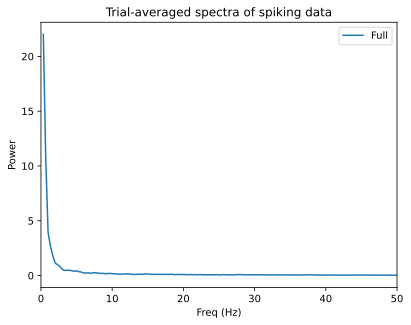

In [10]:
def mt_specpb(data, Fs=1000, NW=1, trial_ave=True):
    
    tapers, _ = dpss_windows(data.shape[-1], NW, 2*NW-1) # Compute the tapers,
    tapers *= sqrt(Fs)                                   # ... and scale them.
    
    dataT = [[trial * t for t in tapers] for trial in data] 
    T = rfft(tapers)                                 # Compute the fft of the tapers.
    J = rfft(dataT)                                  # Compute the fft of the tapered data.
    # Recall that rfft assumes the data are real, and thus 
    J -= [T * trial.mean() for trial in data]            # Subtract the dc (**)
    J *= J.conj()                                        # Compute the spectrum
    S = J.mean(1).real
    f = rfftfreq(data.shape[-1], 1 / Fs)
    if trial_ave : S = S.mean(0)                         # Average across trials.
    return f, S


# f, S_pre = mt_specpb(spike_trains[:, 0:30000])  # Compute the spectrum of the planning period
# _, S_stim = mt_specpb(spike_trains[:, 30000:60000])  # ... and the movement period
f_full, S_full = mt_specpb(spike_trains)  # ... and the full trial

# plot(f, S_pre, label="Pre")        # Plot the planning period,
# plot(f, S_stim, label="Stim")        # ... and the movement period
plot(f_full, S_full/f_full, label="Full")        # ... and the full trial
plt.xlim(0, 50)                         # ... zoom in,
xlabel('Freq (Hz)')                     # ... with axes labeled
ylabel('Power')
legend()
title('Trial-averaged spectra of spiking data');

In [11]:
avg_spike_train = np.mean(spike_trains, axis = 0)
# avg_spike_train

In [12]:
# # convolve spike_trains with an exponential
# tau = .0001
# t = np.arange(0, 3, 1/Fs)
# kernel = np.exp(-t/tau)
# kernel = kernel / sum(kernel)
# smoothed = np.array([np.convolve(trial, kernel, mode='same') for trial in spike_trains])
# smoothed

array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [6.71387946e-079, 3.04809656e-083, 1.38383370e-087, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       ...,
       [9.85922892e-305, 4.47608300e-309, 2.03213854e-313, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 9.99954600e-001, 4.53978686e-005, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000],
       [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
        0.00000000e+000, 0.00000000e+000, 0.00000000e+000]])

In [14]:
# convolve spike_trains with a gaussian
sigma = .0001
t = np.arange(0, 3, 1/Fs)
kernel = np.exp(-t**2/(2*sigma**2))
kernel = kernel / sum(kernel)
smoothed = np.array([np.convolve(trial, kernel, mode='same') for trial in spike_trains])

/var/folders/mq/6f6ky9r97r1_mqfg3vjq9fd00000gn/T/ipykernel_93671/2804112457.py:18: RuntimeWarning: divide by zero encountered in divide
  Z = Z / f[:, None]


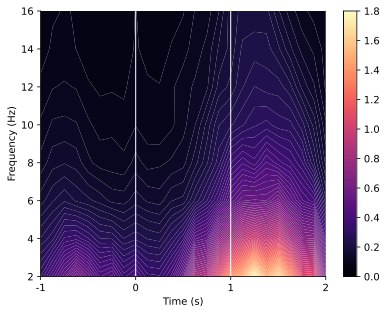

In [15]:
window, step = .5, .1 # define the duration and step size for the spectrogram in seconds.
fpass = [0, 60] # define the frequency band of interest,
Fs = 1000
t = np.arange(-fs, fs * 2, 1) / Fs

window, step = [int(Fs * x) for x in [window, step]]
# starts = range(0, avg_spike_train.shape[-1] - window, step)
starts = range(0, spike_trains.shape[-1] - window, step)
f = mt_specpb(spike_trains[:, range(window)], NW=1)[0]
# f = mt_specpb(avg_spike_train[range(window)], NW=2, trial_ave=False)[0]
findx = (f >= fpass[0]) & (f <= fpass[1])
f = f[findx]

# spectrogram = [mt_specpb(avg_spike_train[range(s, s + window)], NW=2)[1][findx] for s in starts]
spectrogram = [mt_specpb(spike_trains[:, range(s, s + window)], NW=2)[1][findx] for s in starts]
Z = ndimage.gaussian_filter(array(spectrogram).T, 0.25)
# scale Z by f
Z = Z / f[:, None]

# Aesthetics
contourf(np.linspace(-1, 2, len(starts)), f, Z, cmap = 'magma', levels = 100)
xlabel('Time (s)')
ylabel('Frequency (Hz)')
colorbar()
plt.ylim(2, 16)
plt.axvline(0, color = 'white', linestyle = '-', linewidth = 1)
plt.axvline(1, color = 'white', linestyle = '-', linewidth = 1)
plt.xticks([-1, 0, 1, 2], ['-1', '0', '1', '2'])
sns.despine(top = True, right = True)

# Export & Display
plt.savefig('/Users/justincampbell/Desktop/TEST.png', dpi = 1200, bbox_inches = 'tight')
show()

## TEST

In [ ]:
from scipy.io import loadmat

In [ ]:
data = loadmat('/Users/justincampbell/Desktop/Ch10-spikes-1.mat')           # Load the spike train data.
t = data['t'][0] 
train = data['train']  

In [ ]:
imshow(train, aspect='auto',cmap='gray_r')
show()

In [ ]:
spiketrials, spiketimes = where(train)
ISIs = diff(spiketimes)                     #Compute ISIs for all trials,
ISIs = ISIs[where(ISIs > 0)]                #... and ignore ISIs "across trials"
hist = histogram(ISIs, 250)[0]              #Compute histogram of ISIs,
bar(linspace(0, 250, 250), hist, width = 1) #... and plot it.
xlabel('Interspike Interval (ms)')
ylabel('Count')
title('Histogram of ISIs')
show()

In [ ]:
def mt_specpb(data, Fs=1000, NW=4, trial_ave=True):
    
    tapers, _ = dpss_windows(data.shape[-1], NW, 2*NW-1) # Compute the tapers,
    tapers *= sqrt(Fs)                                   # ... and scale them.
    
    dataT = [[trial * t for t in tapers]                 # Multiply the data by the tapers,
             for trial in data]                          # ... for each trial in the data.
    T = rfft(tapers)                                 # Compute the fft of the tapers.
    J = rfft(dataT)                                  # Compute the fft of the tapered data.
    # Recall that rfft assumes the data are real, and thus 
    J -= [T * trial.mean() for trial in data]            # Subtract the dc (**)
    J *= J.conj()                                        # Compute the spectrum
    S = J.mean(1).real
    f = rfftfreq(data.shape[-1], 1 / Fs)
    if trial_ave : S = S.mean(0)                         # Average across trials.
    return f, S

fig = plt.figure(figsize = (12, 3))
f, S = mt_specpb(train, Fs = 1000)  # Compute the spectrum of the planning period

plot(f, S, label="Planning")        # Plot the planning period,
xlabel('Freq (Hz)')                     # ... with axes labeled
ylabel('Power (Hz)')
legend()
title('Trial-averaged spectra of spiking data');
plt.xlim(0, 500)
plt.ylim(20, 70)

In [ ]:
train.mean(axis = 1)

In [ ]:
spike_trains.mean(axis = 1)